# Fixed-pair seed-set classification

This notebook studies one fixed correlated graph pair at a time. Every predictor is computed from the candidate seed set in Graph A. The target is whether SGM reaches the selected final-accuracy threshold.

The training data combine random and feature-diverse seed sets. The test data contain only fresh uniformly random seed sets. `paper_pa` is the new preferential-attachment-plus-ER PAPER graph; `paper` is the historical Pareto-weight Chung–Lu graph. For Enron, the fixed pair is two weekly email snapshots; its vertex correspondence is known from the dataset. Saved outputs may reflect a different model, so rerun all cells after changing `GRAPH_MODEL`.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    log_loss,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)


In [2]:
# Choose one: "sparse_er", "sparse_sbm", "paper", "paper_pa", "ier", or "enron"
GRAPH_MODEL = "paper_pa"

EXPERIMENT_DIR = Path.cwd().resolve()
if EXPERIMENT_DIR.name != "fixed_pair_seed_set_classification":
    EXPERIMENT_DIR = EXPERIMENT_DIR / "fixed_pair_seed_set_classification"
DATA_DIR = EXPERIMENT_DIR / "data"
SUCCESS_THRESHOLD = 0.90
RANDOM_STATE = 42


In [3]:
csv_path = DATA_DIR / f"{GRAPH_MODEL}_seed_sets.csv"
metadata_path = DATA_DIR / f"{GRAPH_MODEL}_seed_sets.metadata.json"

data = pd.read_csv(csv_path)
metadata = json.loads(metadata_path.read_text())
feature_columns = [
    column
    for column in metadata["feature_columns"]
    if column in data and data[column].nunique(dropna=True) > 1
]

# Recompute this label here so the threshold can be changed above.
data["sgm_success"] = (
    data["final_unseeded_accuracy"] >= SUCCESS_THRESHOLD
).astype(int)

print(f"Dataset: {csv_path}")
print(f"Rows: {len(data):,}")
print(f"Usable Graph-A features: {len(feature_columns)}")
print(f"Overall success rate: {data['sgm_success'].mean():.1%}")
if GRAPH_MODEL == "enron":
    pair_metadata = json.loads((DATA_DIR / "enron_problem.metadata.json").read_text())
    print(f"Enron weeks: {pair_metadata['weeks_1_based']}; vertices retained: {data['n_vertices'].iloc[0]}")
display(
    data.groupby(["data_split", "sampling_strategy"])
    .agg(
        rows=("candidate_id", "size"),
        success_rate=("sgm_success", "mean"),
        mean_final_accuracy=("final_unseeded_accuracy", "mean"),
    )
    .round(3)
)


Dataset: /Users/langsong/Desktop/Seeded-Graph-Matching/fixed_pair_seed_set_classification/data/paper_pa_seed_sets.csv
Rows: 1,000
Usable Graph-A features: 15
Overall success rate: 55.3%


rows  success_rate  mean_final_accuracy
data_split sampling_strategy                                         
test       random              100         0.530                0.718
train      feature_diverse     400         0.535                0.722
           random              500         0.572                0.754

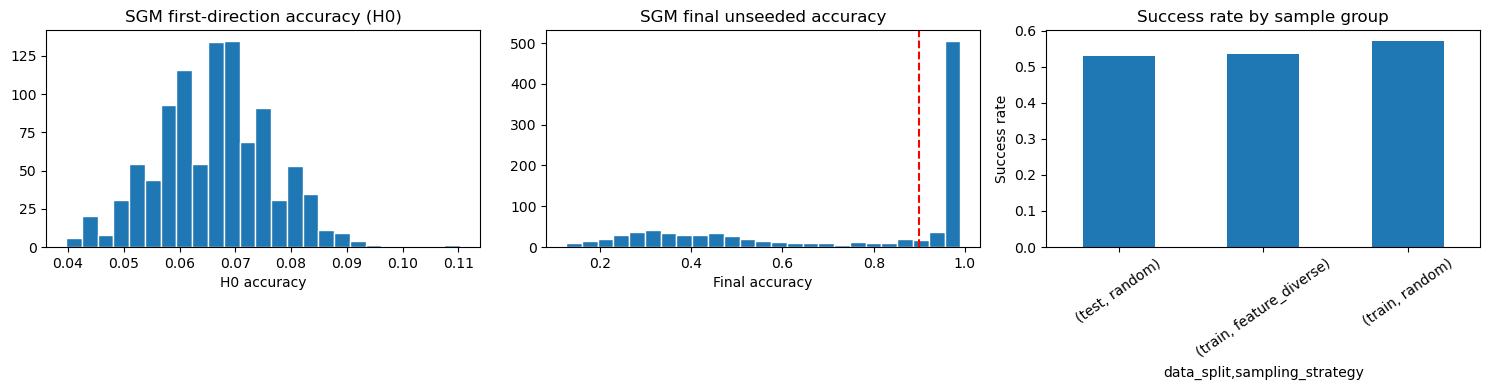

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data["h0_accuracy"], bins=25, edgecolor="white")
axes[0].set_title("SGM first-direction accuracy (H0)")
axes[0].set_xlabel("H0 accuracy")

axes[1].hist(data["final_unseeded_accuracy"], bins=25, edgecolor="white")
axes[1].axvline(SUCCESS_THRESHOLD, color="red", linestyle="--")
axes[1].set_title("SGM final unseeded accuracy")
axes[1].set_xlabel("Final accuracy")

success_by_group = (
    data.groupby(["data_split", "sampling_strategy"])["sgm_success"]
    .mean()
    .sort_values()
)
success_by_group.plot.bar(ax=axes[2])
axes[2].set_title("Success rate by sample group")
axes[2].set_ylabel("Success rate")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


In [5]:
def safe_spearman(x, y):
    valid = x.notna() & y.notna()
    return spearmanr(x[valid], y[valid]).statistic

feature_summary = data[feature_columns].agg(
    ["mean", "std", "min", "median", "max"]
).T
feature_summary["spearman_final_accuracy"] = [
    safe_spearman(data[column], data["final_unseeded_accuracy"])
    for column in feature_columns
]
feature_summary["spearman_h0"] = [
    safe_spearman(data[column], data["h0_accuracy"])
    for column in feature_columns
]
feature_summary["success_mean_difference"] = [
    data.loc[data["sgm_success"].eq(1), column].mean()
    - data.loc[data["sgm_success"].eq(0), column].mean()
    for column in feature_columns
]
feature_summary["absolute_final_correlation"] = feature_summary[
    "spearman_final_accuracy"
].abs()

display(
    feature_summary.sort_values(
        "absolute_final_correlation", ascending=False
    ).round(4)
)


,mean,std,min,median,max,spearman_final_accuracy,spearman_h0,success_mean_difference,absolute_final_correlation
nonseed_seed_signature_normalized_entropy,0.1457,0.0217,0.0933,0.1417,0.2219,0.2262,0.4290,0.0096,0.2262
nonseed_nearest_seed_distance_mean,2.1726,0.1091,1.8155,2.1931,2.4655,-0.2148,-0.3839,-0.0450,0.2148
nonseed_seed_signature_collision_pair_fraction,0.7032,0.0555,0.4997,0.7147,0.8257,-0.2074,-0.4050,-0.0203,0.2074
nonseed_covered_fraction,0.1633,0.0352,0.0914,0.1552,0.3017,0.2044,0.4013,0.0124,0.2044
seed_degree_mean,5.4524,1.2368,3.1500,5.1000,10.1500,0.1950,0.4143,0.4079,0.1950
seed_pagerank_mean,0.0018,0.0003,0.0011,0.0017,0.0031,0.1907,0.4156,0.0001,0.1907
nonseed_covered_by_two_fraction,0.0154,0.0069,0.0017,0.0138,0.0431,0.1397,0.3849,0.0017,0.1397
seed_betweenness_mean,0.0063,0.0054,0.0014,0.0042,0.0290,0.1256,0.3558,0.0007,0.1256
nonseed_three_hop_seed_count_mean,6.6111,0.7914,4.3845,6.5629,8.8810,0.1176,0.2188,0.1923,0.1176
seed_pair_shortest_path_mean,3.7716,0.1933,3.1579,3.7789,4.3579,-0.1126,-0.2276,-0.0444,0.1126


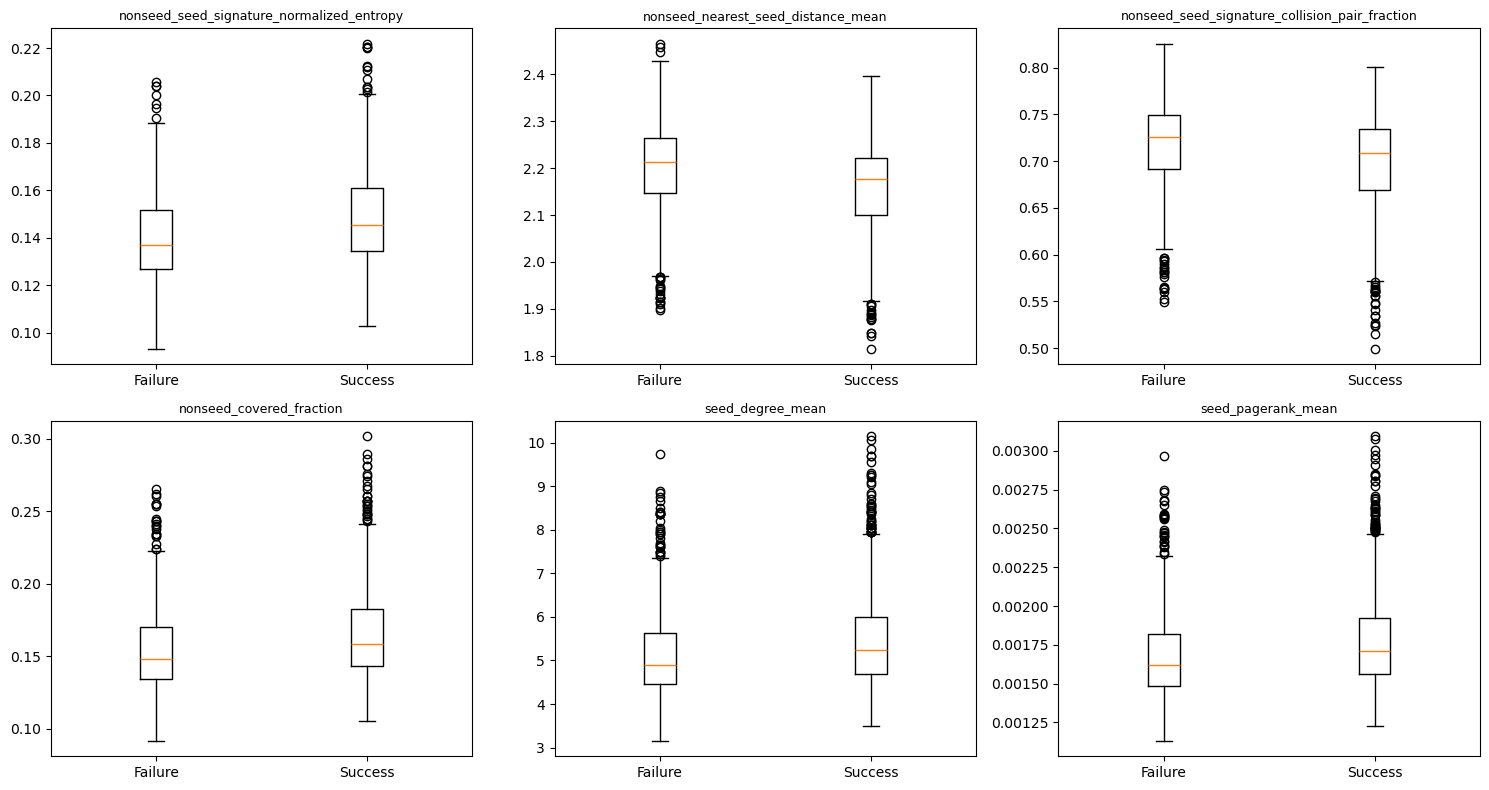

In [6]:
top_features = (
    feature_summary.sort_values("absolute_final_correlation", ascending=False)
    .head(6)
    .index
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.ravel(), top_features):
    failed = data.loc[data["sgm_success"].eq(0), column].dropna()
    succeeded = data.loc[data["sgm_success"].eq(1), column].dropna()
    ax.boxplot([failed, succeeded], tick_labels=["Failure", "Success"])
    ax.set_title(column, fontsize=9)
plt.tight_layout()
plt.show()


## Feature relationships with final accuracy

Each point is one seed set. The orange line is the median final accuracy within feature quantiles, and the shaded band is the interquartile range. The dashed line marks the success threshold. Broad vertical scatter means that the feature is informative on average but cannot determine performance by itself.


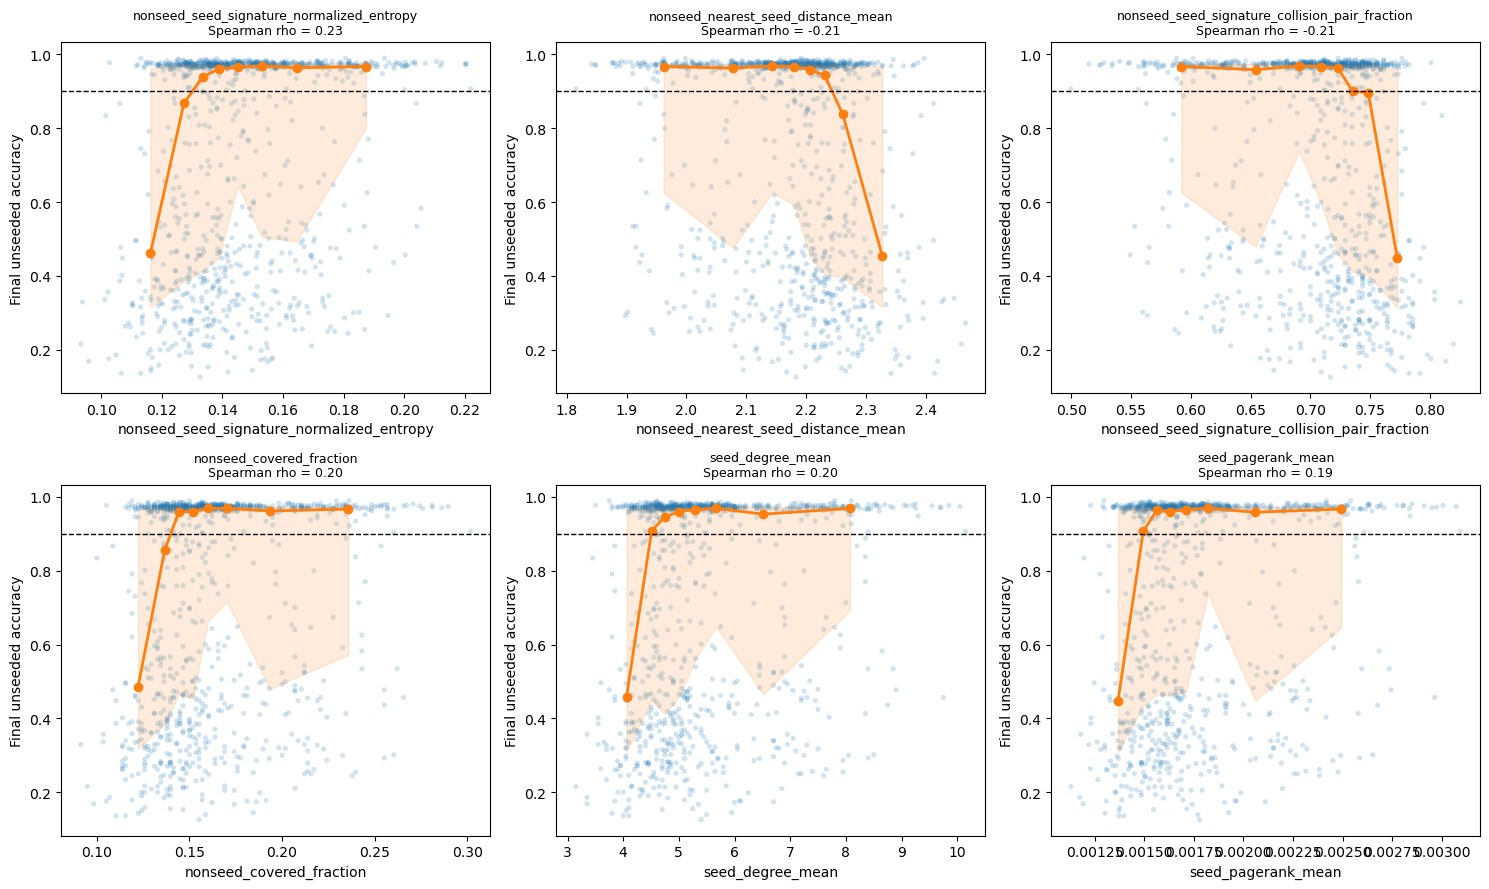

In [7]:
# Use all rows to show the available feature range. To inspect only the
# fresh random test sets, replace this with data.query("data_split == 'test'").
scatter_data = data

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, column in zip(axes.ravel(), top_features):
    plot_data = scatter_data[[column, "final_unseeded_accuracy"]].dropna()
    ax.scatter(
        plot_data[column],
        plot_data["final_unseeded_accuracy"],
        s=14,
        alpha=0.20,
        color="tab:blue",
        edgecolors="none",
    )

    n_bins = min(8, plot_data[column].nunique())
    if n_bins >= 2:
        bins = pd.qcut(plot_data[column], q=n_bins, duplicates="drop")
        trend = (
            plot_data.assign(feature_bin=bins)
            .groupby("feature_bin", observed=True)
            .agg(
                feature_mean=(column, "mean"),
                accuracy_median=("final_unseeded_accuracy", "median"),
                accuracy_q25=(
                    "final_unseeded_accuracy", lambda values: values.quantile(0.25)
                ),
                accuracy_q75=(
                    "final_unseeded_accuracy", lambda values: values.quantile(0.75)
                ),
            )
            .sort_values("feature_mean")
        )
        x_values = trend["feature_mean"].to_numpy()
        ax.plot(
            x_values,
            trend["accuracy_median"].to_numpy(),
            color="tab:orange",
            marker="o",
            linewidth=2,
        )
        ax.fill_between(
            x_values,
            trend["accuracy_q25"].to_numpy(),
            trend["accuracy_q75"].to_numpy(),
            color="tab:orange",
            alpha=0.15,
        )

    correlation = safe_spearman(
        plot_data[column], plot_data["final_unseeded_accuracy"]
    )
    ax.axhline(SUCCESS_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{column}\nSpearman rho = {correlation:.2f}", fontsize=9)
    ax.set_xlabel(column)
    ax.set_ylabel("Final unseeded accuracy")

plt.tight_layout()
plt.show()


In [8]:
train = data.loc[data["data_split"].eq("train")].copy()
test = data.loc[data["data_split"].eq("test")].copy()

X_train = train[feature_columns]
y_train = train["sgm_success"]
X_test = test[feature_columns]
y_test = test["sgm_success"]

models = {
    "Logistic regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
    "Random forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
}

probabilities = {}
metric_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    probabilities[name] = probability
    metric_rows.append(
        {
            "model": name,
            "test_roc_auc": roc_auc_score(y_test, probability),
            "test_average_precision": average_precision_score(
                y_test, probability
            ),
            "test_balanced_accuracy": balanced_accuracy_score(
                y_test, prediction
            ),
            "test_log_loss": log_loss(y_test, probability),
        }
    )

metrics = pd.DataFrame(metric_rows).set_index("model")
display(metrics.round(4))


,test_roc_auc,test_average_precision,test_balanced_accuracy,test_log_loss
model,,,,
Logistic regression,0.6981,0.6977,0.6576,0.6357
Random forest,0.6519,0.6450,0.5998,0.6565


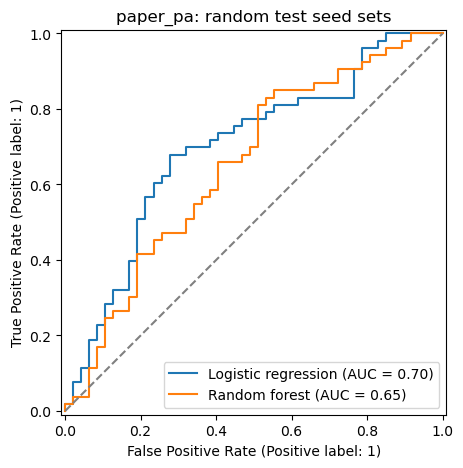

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, probability in probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test, probability, name=name, ax=ax
    )
ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
ax.set_title(f"{GRAPH_MODEL}: random test seed sets")
plt.show()


,feature,importance_mean,importance_std
6,nonseed_nearest_seed_distance_mean,0.0479,0.0271
2,seed_betweenness_mean,0.0402,0.0168
10,nonseed_seed_signature_normalized_entropy,0.0164,0.0246
14,seed_community_normalized_entropy,0.0117,0.0116
11,nonseed_seed_signature_collision_pair_fraction,0.0114,0.0084
12,seed_nonseed_neighborhood_jaccard_mean,0.0091,0.0106
3,nonseed_covered_fraction,0.0077,0.0061
7,nonseed_nearest_seed_distance_max,0.0000,0.0000
5,nonseed_covered_by_three_fraction,-0.0008,0.0053
1,seed_pagerank_mean,-0.0017,0.0111


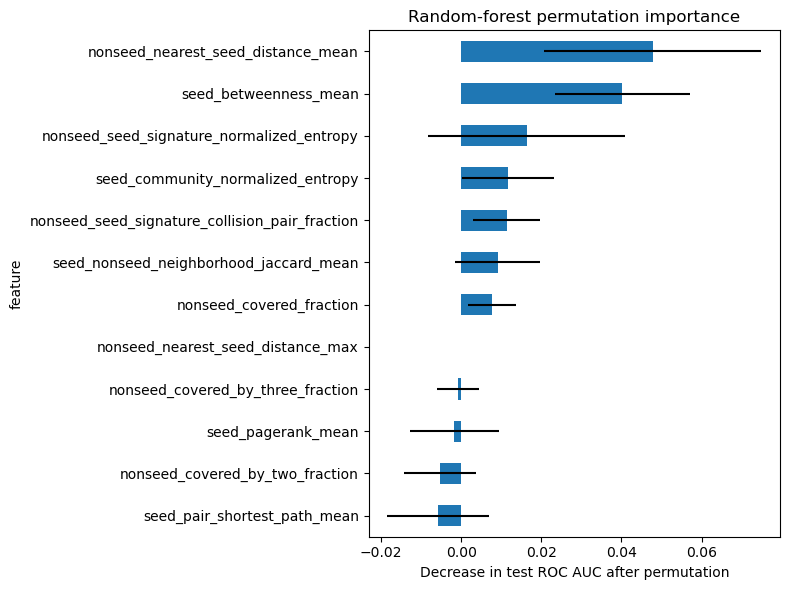

In [10]:
random_forest = models["Random forest"]
importance = permutation_importance(
    random_forest,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_table = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(importance_table.head(15).round(4))

importance_table.head(12).sort_values("importance_mean").plot.barh(
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    figsize=(8, 6),
    legend=False,
)
plt.xlabel("Decrease in test ROC AUC after permutation")
plt.title("Random-forest permutation importance")
plt.tight_layout()
plt.show()


In [11]:
ranked_test = test[
    ["candidate_id", "final_unseeded_accuracy", "sgm_success"]
].copy()
ranked_test["predicted_success_probability"] = probabilities["Random forest"]
ranked_test = ranked_test.sort_values(
    "predicted_success_probability", ascending=False
)

random_mean_accuracy = test["final_unseeded_accuracy"].mean()
random_success_rate = test["sgm_success"].mean()
oracle_accuracy = test["final_unseeded_accuracy"].max()

ranking_rows = []
for fraction in [0.01, 0.05, 0.10, 0.20]:
    count = max(1, int(np.ceil(fraction * len(ranked_test))))
    selected = ranked_test.head(count)
    ranking_rows.append(
        {
            "top_fraction": fraction,
            "selected_count": count,
            "selected_mean_accuracy": selected[
                "final_unseeded_accuracy"
            ].mean(),
            "selected_success_rate": selected["sgm_success"].mean(),
            "accuracy_gain_over_random": selected[
                "final_unseeded_accuracy"
            ].mean()
            - random_mean_accuracy,
            "regret_from_best_observed": oracle_accuracy
            - selected["final_unseeded_accuracy"].max(),
        }
    )

print(f"Random-test mean accuracy: {random_mean_accuracy:.3f}")
print(f"Random-test success rate: {random_success_rate:.1%}")
print(f"Best observed test accuracy: {oracle_accuracy:.3f}")
display(pd.DataFrame(ranking_rows).round(4))
display(ranked_test.head(10))


Random-test mean accuracy: 0.718
Random-test success rate: 53.0%
Best observed test accuracy: 0.981


,top_fraction,selected_count,selected_mean_accuracy,selected_success_rate,accuracy_gain_over_random,regret_from_best_observed
0,0.01,1,0.9707,1.0,0.2531,0.0103
1,0.05,5,0.5800,0.4,-0.1376,0.0086
2,0.10,10,0.7224,0.6,0.0048,0.0052
3,0.20,20,0.7759,0.7,0.0582,0.0034


,candidate_id,final_unseeded_accuracy,sgm_success,predicted_success_probability
998,998,0.970690,1,0.815706
961,961,0.360345,0,0.755864
989,989,0.972414,1,0.740471
932,932,0.317241,0,0.738319
935,935,0.279310,0,0.733819
930,930,0.962069,1,0.730998
996,996,0.975862,1,0.726267
985,985,0.962069,1,0.725359
987,987,0.970690,1,0.709688
943,943,0.453448,0,0.692451


## Questions to answer from the output

1. Does the fixed pair contain both successful and unsuccessful random test seed sets?
2. Are feature distributions visibly different between the two classes?
3. Does the random-forest test AUC materially exceed 0.5?
4. Do the model's top-ranked sets outperform the full random test sample?
5. Are the same coverage, distance, and redundancy features important across graph models?

A result on one fixed pair is evidence about that particular matching problem. Repeat the notebook for all five datasets before deciding whether a feature relationship transfers across graph models. Enron is a real-data stress test, not another draw from the synthetic models.
